# Tutorial: Matrices con SymPy y Diagramas de Transición con NetworkX

## 0. Instalación e importación de librerías

In [20]:
from sympy import *
import networkx as nx
import matplotlib.pyplot as plt

# Esto hace que SymPy muestre los resultados de forma bonita
init_printing(use_unicode=True)

---
## 1. ¿Cómo representar una matriz en SymPy?

Usamos `Matrix()` y pasamos una lista de listas (cada lista interna es una fila).

In [21]:
# Definimos una matriz 3x3
A = Matrix([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

print("Nuestra matriz A:")
A

Nuestra matriz A:


⎡1  2  3⎤
⎢       ⎥
⎢4  5  6⎥
⎢       ⎥
⎣7  8  9⎦

In [22]:
# También podemos definir una segunda matriz
B = Matrix([
    [2, 0, 1],
    [1, 3, 0],
    [0, 1, 2]
])

print("Nuestra matriz B:")
B

Nuestra matriz B:


⎡2  0  1⎤
⎢       ⎥
⎢1  3  0⎥
⎢       ⎥
⎣0  1  2⎦

---
## 2. Obtener filas, columnas y entradas específicas

In [23]:
# Obtener la primera fila (índice 0)
print("Primera fila de A:")
A.row(0)

Primera fila de A:


[1  2  3]

In [24]:
# Obtener la segunda columna (índice 1)
print("Segunda columna de A:")
A.col(1)

Segunda columna de A:


⎡2⎤
⎢ ⎥
⎢5⎥
⎢ ⎥
⎣8⎦

In [25]:
# Obtener una entrada específica: fila 1, columna 2 (es el número 6)
print("Entrada en fila 1, columna 2:")
A[1, 2]

Entrada en fila 1, columna 2:


6

---
## 3. Multiplicar matrices

En SymPy se multiplican matrices con el operador `*`.

In [26]:
# Multiplicación de matrices A * B
print("AB =")
A * B

AB =


⎡4   9   7 ⎤
⎢          ⎥
⎢13  21  16⎥
⎢          ⎥
⎣22  33  25⎦

In [27]:
# la multiplicación de matrices no es conmutativa en general
print("BA =")
B * A

BA =


⎡9   12  15⎤
⎢          ⎥
⎢13  17  21⎥
⎢          ⎥
⎣18  21  24⎦

---
## 4. Elevar una matriz a una potencia

Se usa el operador `**` igual que con los números normales.

In [28]:
# Elevar B al cuadrado (B^2 = B * B)
print("B al cuadrado:")
B**2

B al cuadrado:


⎡4  1  4⎤
⎢       ⎥
⎢5  9  1⎥
⎢       ⎥
⎣1  5  4⎦

In [29]:
# Elevar B a la tercera potencia
print("B al cubo:")
B**3

B al cubo:


⎡9   7   12⎤
⎢          ⎥
⎢19  28  7 ⎥
⎢          ⎥
⎣7   19  9 ⎦

---
## 5. Multiplicar un vector por una matriz

Un vector se puede representar como una matriz de una sola columna (vector columna).

In [30]:
# Definimos un vector columna
v = Matrix([1, 0, 1])  # Vector de 3 entradas

print("Vector v:")
v

Vector v:


⎡1⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣1⎦

In [40]:
# Multiplicamos la matriz B por el vector v
# Resultado: otro vector
print("Bv =")
B * v

Bv =


⎡3⎤
⎢ ⎥
⎢1⎥
⎢ ⎥
⎣2⎦

---
## 6. Valores propios y vectores propios (Eigenvalores y Eigenvectores)

Usaremos una matriz más sencilla para este ejemplo.

In [32]:
# Definimos una matriz 2x2 sencilla
C = Matrix([
    [3, 1],
    [0, 2]
])

print("Matriz C:")
C

Matriz C:


⎡3  1⎤
⎢    ⎥
⎣0  2⎦

In [33]:
# Valores propios
# Devuelve: {valor_propio: multiplicidad}
print("Valores propios de C:")
C.eigenvals()

Valores propios de C:


{2: 1, 3: 1}

In [34]:
# Vectores propios
# Devuelve: (valor_propio, multiplicidad, [vectores])
print("Vectores propios de C:")
C.eigenvects()

Vectores propios de C:


⎡⎛      ⎡⎡-1⎤⎤⎞  ⎛      ⎡⎡1⎤⎤⎞⎤
⎢⎜2, 1, ⎢⎢  ⎥⎥⎟, ⎜3, 1, ⎢⎢ ⎥⎥⎟⎥
⎣⎝      ⎣⎣1 ⎦⎦⎠  ⎝      ⎣⎣0⎦⎦⎠⎦

---
## 7. Diagrama de Transición con NetworkX

Un diagrama de transición es un grafo dirigido donde:
- Los nodos representan estados
- Las flechas representan transiciones entre estados
- Las etiquetas en las flechas indican la probabilidad de cada transición

### Ejemplo: Un sistema con 3 estados (A, B, C) y transiciones A->B, B->C, C->A.

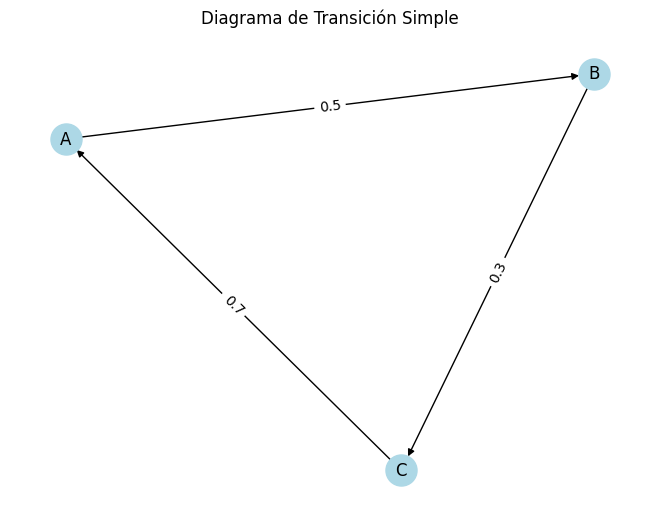

In [41]:
# Crear un grafo dirigido
G = nx.DiGraph()

# Agregar nodos (estados)
G.add_nodes_from(['A', 'B', 'C'])

# Agregar aristas (transiciones)
G.add_edge('A', 'B', label='0.5')
G.add_edge('B', 'C', label='0.3')
G.add_edge('C', 'A', label='0.7')

# Dibujar el grafo
pos = nx.spring_layout(G)  # Posición de los nodos
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500, arrows=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels={('A','B'):'0.5', ('B','C'):'0.3', ('C','A'):'0.7'})
plt.title("Diagrama de Transición Simple")
plt.show()